## Fourier Series (Lab3)
All of examples are given by Prof. Sinan Xiao from Shien-Ming Wu School of Intelligent Engineering, SCUT Spring 2026 
 
 V3nt1_onthemic organized the lab content and summarized it, adapting the original MATLAB teaching materials to Python for signal and system applications and exercises

### SYLLABUS:

- Introduction to Fourier Series: Definition and significance.
- Mathematical Formulation: Complex exponential and trigonometric forms.
- Periodic Signal Representation: Decomposition of periodic signals into harmonic components.
- Convergence of Fourier Series: Conditions for convergence.
- Using MATLAB to compute and visualize Fourier series.

### OBJECTIVES:

- Understand the concept of Fourier series and its application in signal processing.
- Calculate the Fourier series coefficients of a periodic signal.
- Use MATLAB to plot a periodic signal and its Fourier series approximation.
- Analyze the convergence properties of Fourier series.

### SOFTWARE USED:

Python 3.12

### THEORY:

#### Definition of Fourier Series:

A periodic signal \( x(t) \) with period \( T \) can be represented as a linear combination of harmonically related complex exponentials:

$$ x(t) = \sum_{k = -\infty}^{+\infty} a_k e^{jk\omega_0 t} = \sum_{k = -\infty}^{+\infty} a_k e^{jk\left(\frac{2\pi}{T}\right)t} \qquad (1.1) $$

$$ a_k = \frac{1}{T} \int_T x(t) e^{-jk\omega_0 t} \, dt = \frac{1}{T} \int_T x(t) e^{-jk\left(\frac{2\pi}{T}\right)t} \, dt \qquad (1.2) $$

where \( \omega_0 = 2\pi / T \) is the fundamental frequency.

#### Trigonometric Form of Fourier Series:

If \( x(t) \) is real, the Fourier series representation can also be expressed using sinusoidal functions:

$$ x(t) = a_0 + 2\sum_{k = 1}^{+\infty} \left[ B_k \cos(k\omega_0 t) - C_k \sin(k\omega_0 t) \right] \qquad (1.3) $$

where \( a_k = B_k + jC_k \), and the coefficients are calculated as:

$$ a_0 = \frac{1}{T} \int_T x(t) \, dt $$

$$ B_k = \frac{1}{T} \int_T x(t) \cos(k\omega_0 t) \, dt $$

$$ C_k = \frac{1}{T} \int_T x(t) \sin(k\omega_0 t) \, dt $$

---

### EXPERIMENT 1: Use the Fourier series representation to approximate a periodic square wave signal

This experiment is to develop the code in MATLAB to use Fourier series representation to approximate a periodic square wave signal. Try to develop the functions based on the equations (1.1) or (1.2) and (1.3) using the given conditions of a periodic square wave, and compare the results with the periodic square wave signal generated using the built-in square function in MATLAB. Please complete the comparison in the following three conditions:

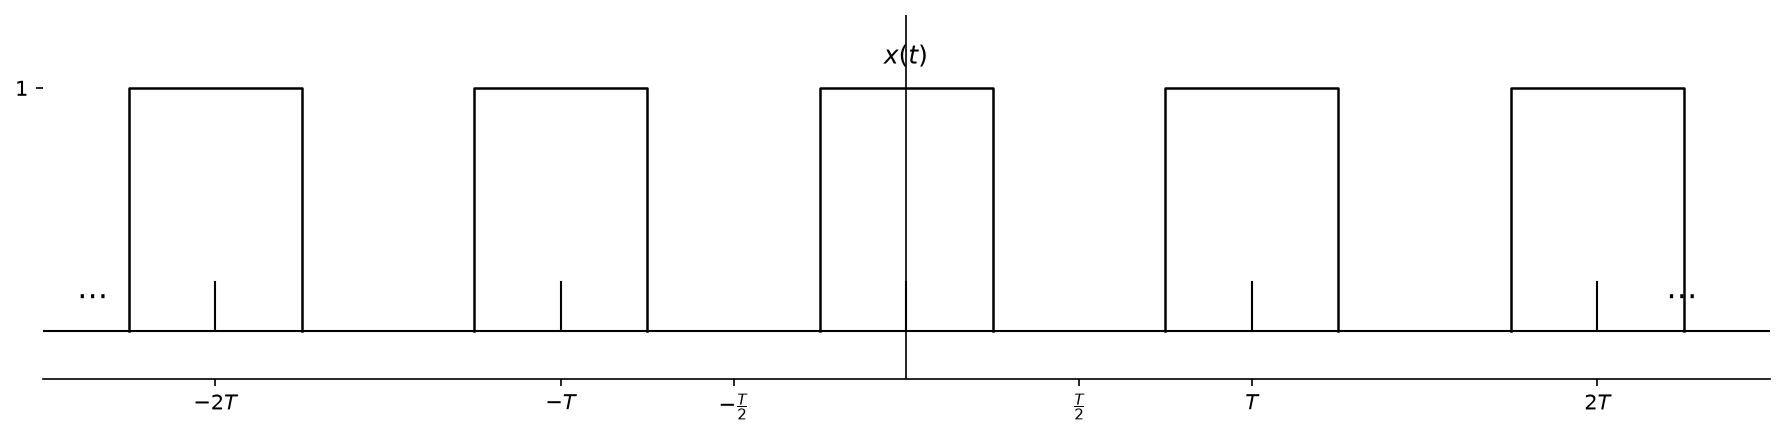

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 设置参数
T = 2  # 周期，可自行修改数值
tau = T / 2  # 脉冲宽度
half_tau = tau / 2  # 半脉宽 T/4
amp = 1  # 脉冲幅度

# 创建画布
plt.figure(figsize=(12, 3), dpi=150)
ax = plt.gca()

# 绘制多个周期的脉冲：n从-2到2
for n in range(-2, 3):
    center = n * T
    t_start = center - half_tau
    t_end = center + half_tau
    # 绘制矩形脉冲
    ax.plot([t_start, t_start, t_end, t_end], [0, amp, amp, 0], color='black', linewidth=1.2)
    # 在脉冲中心画短竖线标记
    ax.plot([center, center], [0, 0.2], color='black', linewidth=1)

# 坐标轴设置
ax.axhline(y=0, color='black', linewidth=1)  # t轴
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 设置横轴刻度与标签
xticks = [-2*T, -T, -T/2, T/2, T, 2*T]
xtick_labels = [r'$-2T$', r'$-T$', r'$-\frac{T}{2}$', r'$\frac{T}{2}$', r'$T$', r'$2T$']
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_xlim(-2.5*T, 2.5*T)
ax.set_ylim(-0.2, 1.3)
ax.set_yticks([1])
ax.set_yticklabels(['1'], fontsize=10)

# 添加x(t)标注
ax.text(0, 1.1, r'$x(t)$', fontsize=12, ha='center')
# 左右省略号
ax.text(-2.4*T, 0.1, r'$\cdots$', fontsize=15)
ax.text(2.2*T, 0.1, r'$\cdots$', fontsize=15)
# 原点竖线
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()


（代码仅用于绘图）

<center>Figure 1. The periodic square wave signal with a period of $T$ and a width of $2T_1$ for each square.</center>

#### (1) Variation of $N$ (Number of Harmonics)

For a periodic square wave shown in Figure 1, when the period $T = 2$ and $T_1 = T/4$, calculate the Fourier series representation of the periodic square wave with different numbers of harmonically related complex exponentials $N = 1, 3, 7, 20, 50,$ and $100$. Plot the resulting signal $x_N(t)$ with different $N$.

#### (2) Variation of $T_1$ (Pulse Width)

For a periodic square wave shown in Figure 1, when the period $T = 2$, calculate the Fourier series representation of the periodic square wave with different values of $T_1 = T/4, T/8,$ and $T/16$. The number of harmonically related complex exponentials $N = 100$. Plot the resulting signal and the magnitude of Fourier series coefficient $|a_k|$ with different $T_1$.

#### (3) Variation of $T$ (Period)

For a periodic square wave shown in Figure 1, when $T_1 = 2$, calculate the Fourier series representation of the periodic square wave with different periods $T = 4T_1, 8T_1,$ and $16T_1$. The number of harmonically related complex exponentials $N = 100$. Plot the resulting signal and the magnitude of Fourier series coefficient $|a_k|$ with different $T$.


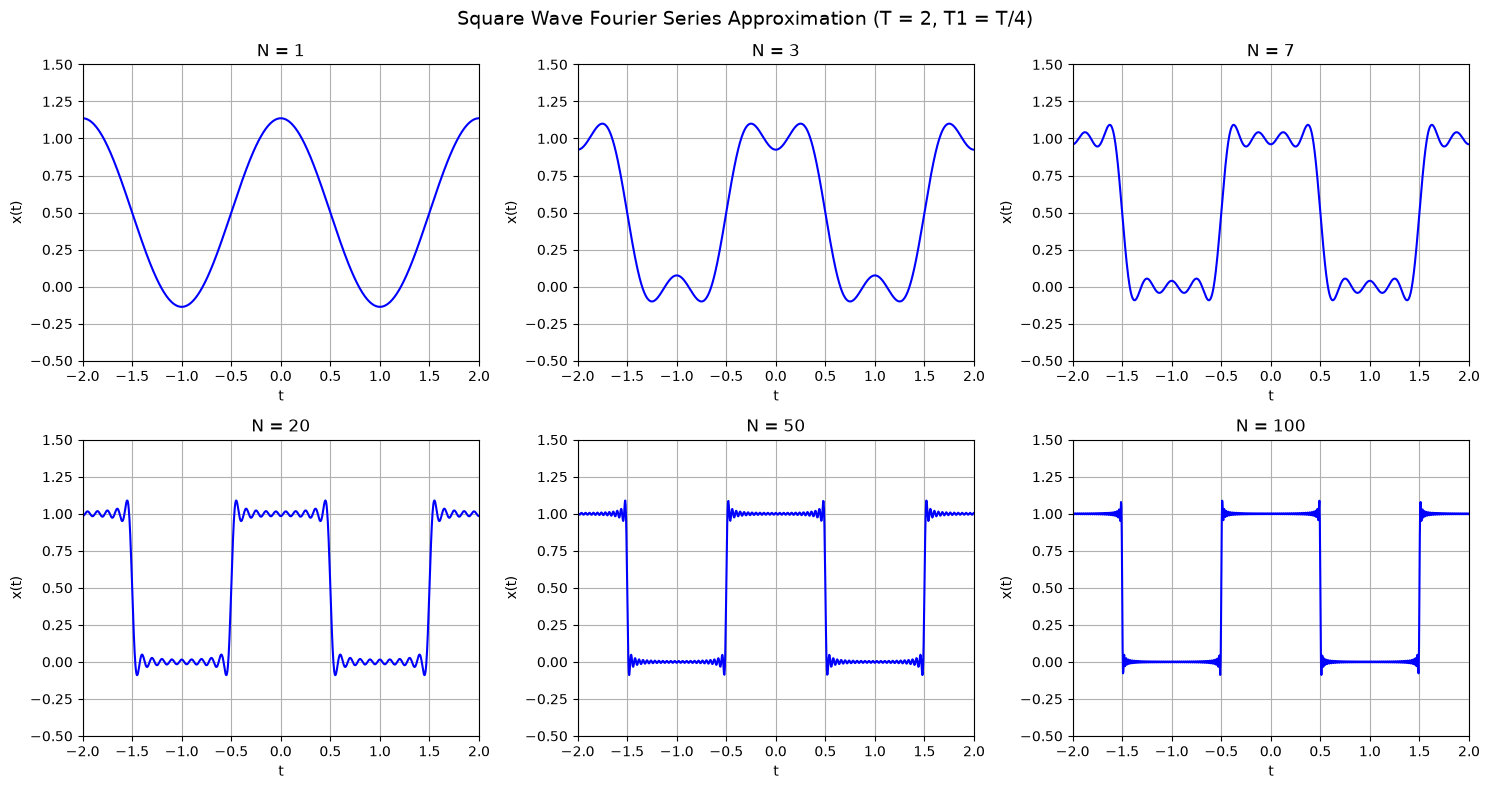

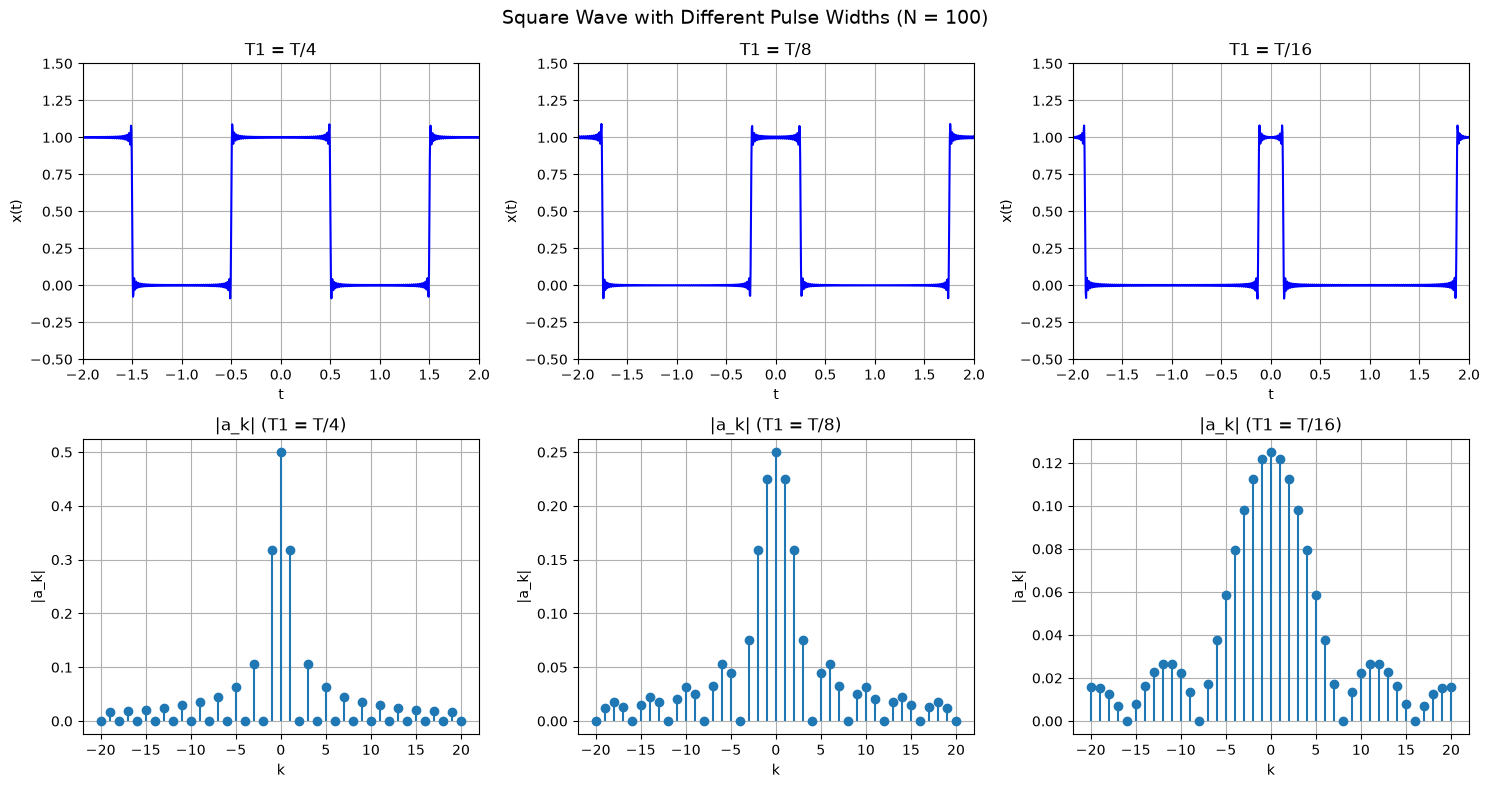

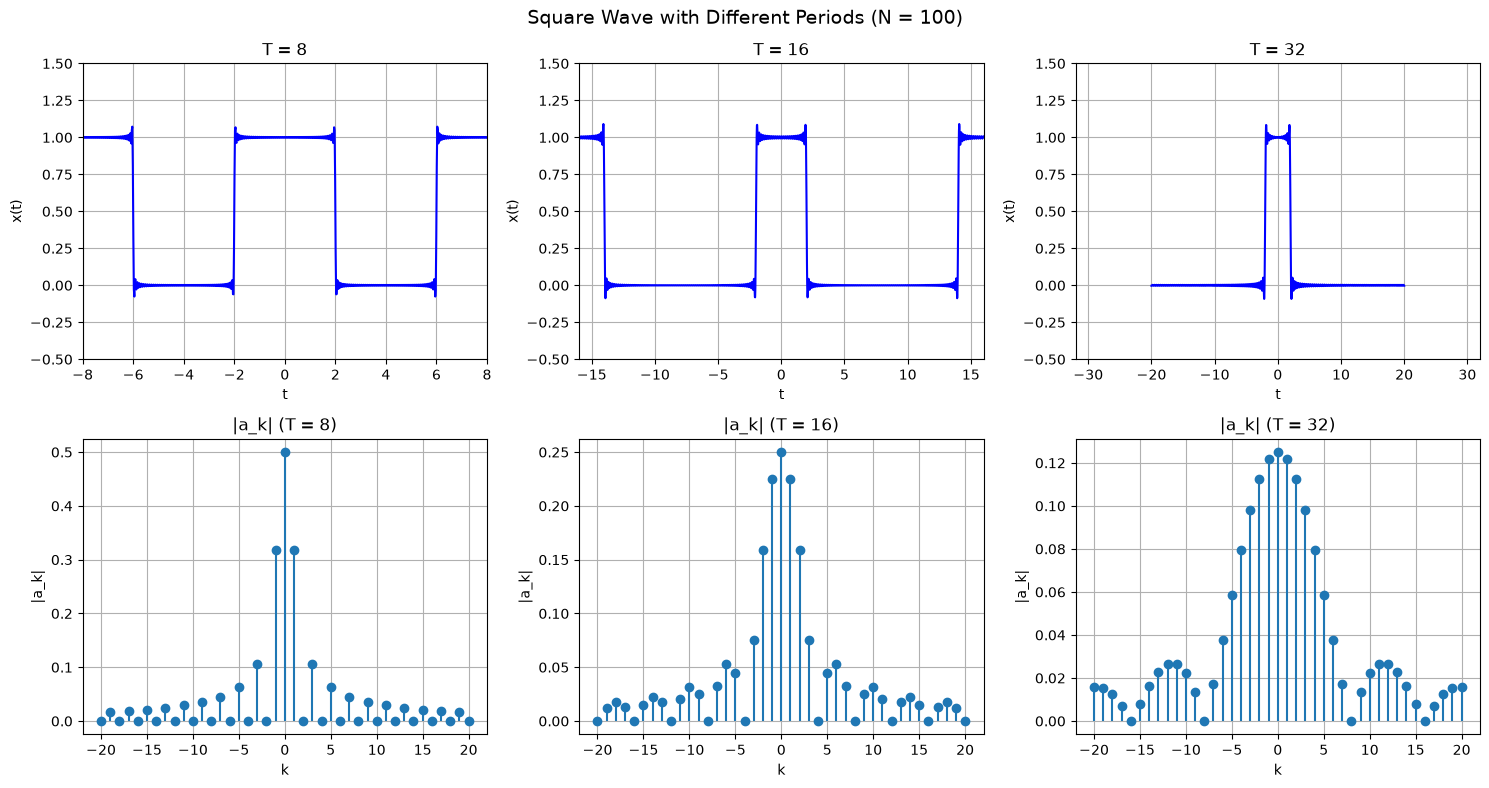

In [3]:
# ============================================================
# Experiment 1: Fourier Series Approximation of Square Wave
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def fourier_square_wave(t, T, T1, N):
    """
    Compute Fourier series approximation of a square wave.
    
    Parameters:
    t : array, time points
    T : float, period
    T1 : float, half-width of the pulse
    N : int, number of harmonics (k = -N to N)
    
    Returns:
    y : array, approximated signal
    """
    omega0 = 2 * np.pi / T
    y = np.zeros_like(t, dtype=complex)
    
    for k in range(-N, N + 1):
        if k == 0:
            a_k = 2 * T1 / T
        else:
            a_k = np.sin(k * omega0 * T1) / (k * np.pi)
        y += a_k * np.exp(1j * k * omega0 * t)
    
    return np.real(y)


# ============================================================
# Experiment 1 (1): Variation of N
# ============================================================

T = 2
T1 = T / 4
N_values = [1, 3, 7, 20, 50, 100]

t = np.linspace(-2, 2, 1000)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, N in enumerate(N_values):
    x_approx = fourier_square_wave(t, T, T1, N)
    axes[idx].plot(t, x_approx, 'b-', linewidth=1.5)
    axes[idx].set_title(f'N = {N}')
    axes[idx].set_xlabel('t')
    axes[idx].set_ylabel('x(t)')
    axes[idx].grid(True)
    axes[idx].set_xlim([-2, 2])
    axes[idx].set_ylim([-0.5, 1.5])

plt.suptitle('Square Wave Fourier Series Approximation (T = 2, T1 = T/4)', fontsize=14)
plt.tight_layout()
plt.savefig('square_wave_vs_N.png', dpi=150)
plt.show()


# ============================================================
# Experiment 1 (2): Variation of T1 (Pulse Width)
# ============================================================

T = 2
T1_values = [T/4, T/8, T/16]
N = 100

t = np.linspace(-2, 2, 1000)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, T1 in enumerate(T1_values):
    # Reconstructed signal
    x_approx = fourier_square_wave(t, T, T1, N)
    axes[0, idx].plot(t, x_approx, 'b-', linewidth=1.5)
    axes[0, idx].set_title(f'T1 = T/{4 * (2**idx)}')
    axes[0, idx].set_xlabel('t')
    axes[0, idx].set_ylabel('x(t)')
    axes[0, idx].grid(True)
    axes[0, idx].set_xlim([-2, 2])
    axes[0, idx].set_ylim([-0.5, 1.5])
    
    # Magnitude of Fourier coefficients
    omega0 = 2 * np.pi / T
    k = np.arange(-20, 21)
    a_k = np.zeros_like(k, dtype=complex)
    for i, kk in enumerate(k):
        if kk == 0:
            a_k[i] = 2 * T1 / T
        else:
            a_k[i] = np.sin(kk * omega0 * T1) / (kk * np.pi)
    
    axes[1, idx].stem(k, np.abs(a_k), basefmt=' ')
    axes[1, idx].set_title(f'|a_k| (T1 = T/{4 * (2**idx)})')
    axes[1, idx].set_xlabel('k')
    axes[1, idx].set_ylabel('|a_k|')
    axes[1, idx].grid(True)

plt.suptitle('Square Wave with Different Pulse Widths (N = 100)', fontsize=14)
plt.tight_layout()
plt.savefig('square_wave_vs_T1.png', dpi=150)
plt.show()


# ============================================================
# Experiment 1 (3): Variation of T (Period)
# ============================================================

T1 = 2
T_values = [4*T1, 8*T1, 16*T1]
N = 100

t = np.linspace(-20, 20, 2000)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, T in enumerate(T_values):
    # Reconstructed signal
    x_approx = fourier_square_wave(t, T, T1, N)
    axes[0, idx].plot(t, x_approx, 'b-', linewidth=1.5)
    axes[0, idx].set_title(f'T = {T}')
    axes[0, idx].set_xlabel('t')
    axes[0, idx].set_ylabel('x(t)')
    axes[0, idx].grid(True)
    axes[0, idx].set_xlim([-T, T])
    axes[0, idx].set_ylim([-0.5, 1.5])
    
    # Magnitude of Fourier coefficients
    omega0 = 2 * np.pi / T
    k = np.arange(-20, 21)
    a_k = np.zeros_like(k, dtype=complex)
    for i, kk in enumerate(k):
        if kk == 0:
            a_k[i] = 2 * T1 / T
        else:
            a_k[i] = np.sin(kk * omega0 * T1) / (kk * np.pi)
    
    axes[1, idx].stem(k, np.abs(a_k), basefmt=' ')
    axes[1, idx].set_title(f'|a_k| (T = {T})')
    axes[1, idx].set_xlabel('k')
    axes[1, idx].set_ylabel('|a_k|')
    axes[1, idx].grid(True)

plt.suptitle('Square Wave with Different Periods (N = 100)', fontsize=14)
plt.tight_layout()
plt.savefig('square_wave_vs_T.png', dpi=150)
plt.show()


### EXPERIMENT 2: Use the Fourier series representation to approximate a periodic triangular wave signal



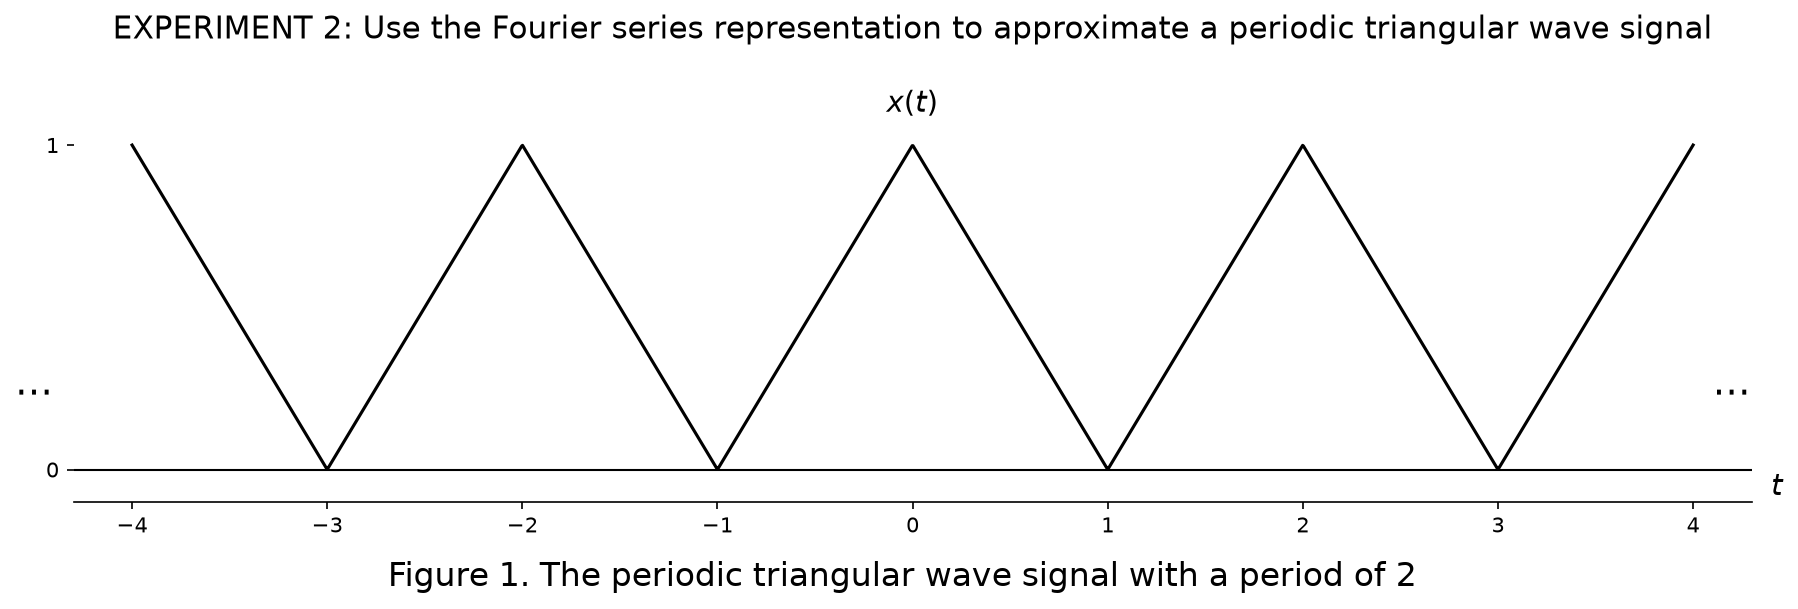

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 参数设置
T = 2       # 周期
amp_max = 1 # 最大幅值
t_total = np.linspace(-4, 4, 2000) # 时间轴采样点

# 2. 周期三角波函数 x(t) = |t mod T - T/2|
def triangle_wave(t, period):
    t_mod = np.mod(t, period)
    # 映射到 [-1,1] 区间，绝对值得到三角波
    shifted = t_mod - period / 2
    return np.abs(shifted)

x = triangle_wave(t_total, T)

# 3. 创建画布绘图
plt.figure(figsize=(12,4), dpi=150)
ax = plt.gca()
ax.plot(t_total, x, color="black", linewidth=1.5)

# 坐标轴美化
ax.axhline(0, color="black", linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# 刻度设置
ax.set_xticks([-4,-3,-2,-1,0,1,2,3,4])
ax.set_yticks([0, 1])
ax.set_ylim(-0.1, 1.2)
ax.set_xlim(-4.3, 4.3)

# 文字标注
ax.text(0, 1.1, r"$x(t)$", fontsize=14, ha="center")
ax.text(-4.6, 0.2, r"$\cdots$", fontsize=18)
ax.text(4.1, 0.2, r"$\cdots$", fontsize=18)
ax.text(4.4, -0.08, r"$t$", fontsize=14)

# 标题与图注
plt.title("EXPERIMENT 2: Use the Fourier series representation to approximate a periodic triangular wave signal", fontsize=15, pad=20)
plt.figtext(0.5, 0.01, "Figure 1. The periodic triangular wave signal with a period of 2", fontsize=16, ha="center")

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) # 给底部图注留出空间
plt.show()


（代码仅用于画图）

Calculate the Fourier series representation of the periodic triangular wave (Figure 2) with different numbers of harmonically related complex exponentials $N = 1, 3, 7, 20, 50,$ and $100$. Plot the resulting signal $x_N(t)$ with different $N$.

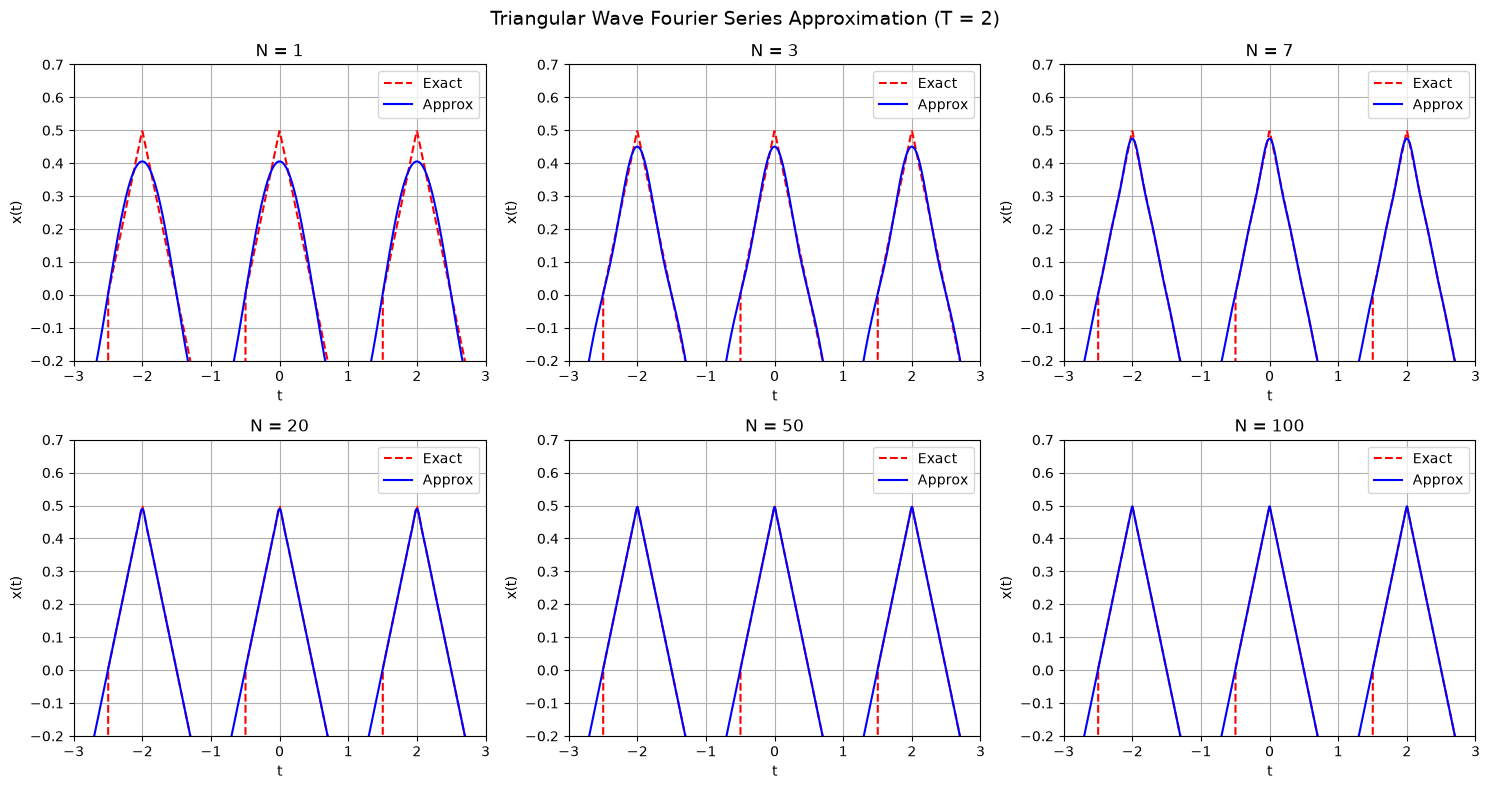

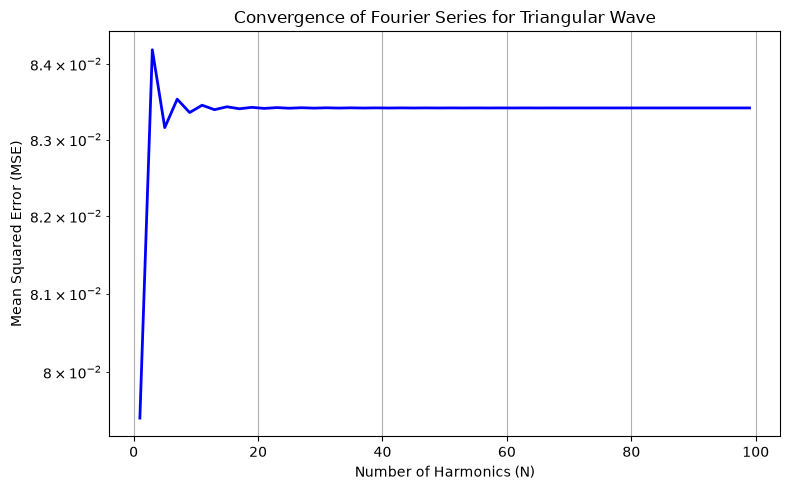

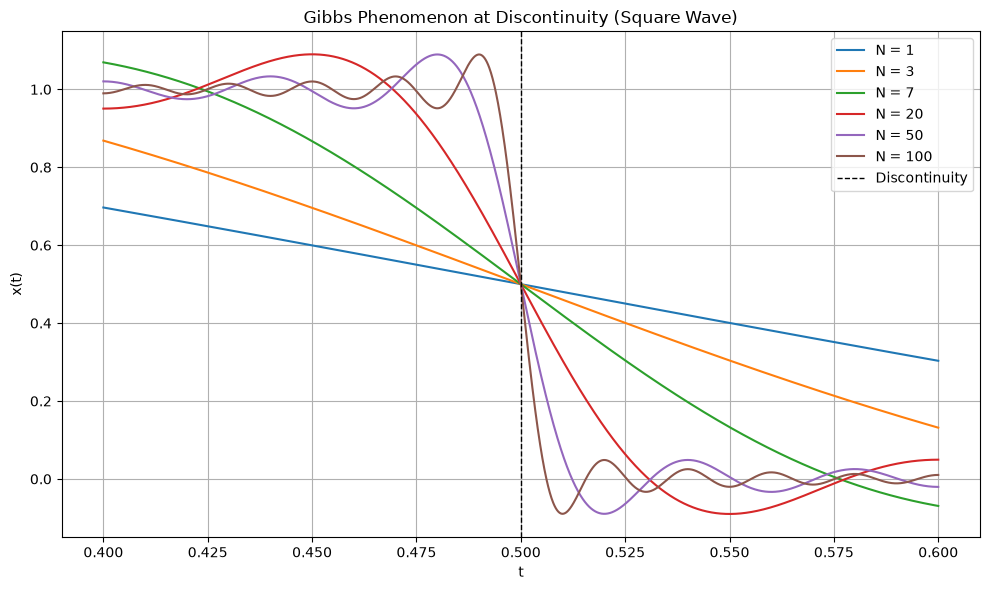

All experiments completed successfully!


In [5]:
# ============================================================
# Experiment 2: Fourier Series Approximation of Triangular Wave
# ============================================================

def fourier_triangular_wave(t, N):
    """
    Compute Fourier series approximation of a triangular wave with period 2.
    
    Parameters:
    t : array, time points
    N : int, number of harmonics (k = -N to N)
    
    Returns:
    y : array, approximated signal
    """
    omega0 = np.pi  # T = 2, omega0 = 2*pi/T = pi
    y = np.zeros_like(t)
    
    for k in range(1, N + 1):
        # Only odd harmonics are non-zero
        if k % 2 == 1:
            a_k = 4 / (k**2 * np.pi**2)
            y += a_k * np.cos(k * omega0 * t)
        # Even harmonics are zero
    
    return y

# Triangular wave exact function for reference
def triangular_wave_exact(t):
    """Exact triangular wave with period 2, amplitude 0.5"""
    t_mod = np.mod(t + 0.5, 2) - 0.5
    return 0.5 - np.abs(t_mod)

# Number of harmonics
N_values = [1, 3, 7, 20, 50, 100]
t = np.linspace(-3, 3, 1000)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, N in enumerate(N_values):
    x_approx = fourier_triangular_wave(t, N)
    axes[idx].plot(t, triangular_wave_exact(t), 'r--', linewidth=1.5, label='Exact')
    axes[idx].plot(t, x_approx, 'b-', linewidth=1.5, label='Approx')
    axes[idx].set_title(f'N = {N}')
    axes[idx].set_xlabel('t')
    axes[idx].set_ylabel('x(t)')
    axes[idx].legend()
    axes[idx].grid(True)
    axes[idx].set_xlim([-3, 3])
    axes[idx].set_ylim([-0.2, 0.7])

plt.suptitle('Triangular Wave Fourier Series Approximation (T = 2)', fontsize=14)
plt.tight_layout()
plt.savefig('triangular_wave.png', dpi=150)
plt.show()


# ============================================================
# Error Analysis: MSE vs Number of Harmonics
# ============================================================

N_test = np.arange(1, 101, 2)  # Only odd harmonics
mse = np.zeros_like(N_test, dtype=float)

t_dense = np.linspace(-2, 2, 2000)

for idx, N in enumerate(N_test):
    x_approx = fourier_triangular_wave(t_dense, N)
    x_exact = triangular_wave_exact(t_dense)
    mse[idx] = np.mean((x_approx - x_exact)**2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(N_test, mse, 'b-', linewidth=2)
ax.set_xlabel('Number of Harmonics (N)')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Convergence of Fourier Series for Triangular Wave')
ax.grid(True)
plt.tight_layout()
plt.savefig('triangular_wave_convergence.png', dpi=150)
plt.show()


# ============================================================
# Gibbs Phenomenon Visualization (Zoom-in at discontinuity)
# ============================================================

# For square wave, zoom at the discontinuity point
T = 2
T1 = T / 4
N_gibbs = [1, 3, 7, 20, 50, 100]
t_zoom = np.linspace(0.4, 0.6, 2000)  # Zoom around t = T1 = 0.5

fig, ax = plt.subplots(figsize=(10, 6))

for N in N_gibbs:
    x_approx = fourier_square_wave(t_zoom, T, T1, N)
    ax.plot(t_zoom, x_approx, linewidth=1.5, label=f'N = {N}')

ax.axvline(x=T1, color='k', linestyle='--', linewidth=1, label='Discontinuity')
ax.set_xlabel('t')
ax.set_ylabel('x(t)')
ax.set_title('Gibbs Phenomenon at Discontinuity (Square Wave)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('gibbs_phenomenon.png', dpi=150)
plt.show()

print("All experiments completed successfully!")

### QUESTIONS:

#### 1. Why can a periodic signal be represented using sine and cosine functions in the Fourier series?

**Answer:**

A periodic signal can be represented using sine and cosine functions because these functions form a **complete orthogonal basis** for the space of periodic signals. The key reasons are:

1. **Orthogonality:** Sine and cosine functions of different frequencies are orthogonal over a period:

   $$ \int_T \cos(m\omega_0 t) \cos(n\omega_0 t) \, dt = 0 \quad (m \neq n) $$

   $$ \int_T \sin(m\omega_0 t) \sin(n\omega_0 t) \, dt = 0 \quad (m \neq n) $$

   $$ \int_T \cos(m\omega_0 t) \sin(n\omega_0 t) \, dt = 0 \quad \forall m, n $$

   This orthogonality allows each frequency component to be extracted independently.

2. **Completeness:** The set of sine and cosine functions at harmonically related frequencies forms a complete basis, meaning any periodic signal can be expressed as a linear combination of these basis functions.

3. **Physical Interpretation:** Sine and cosine functions represent pure sinusoidal oscillations at discrete frequencies. Any periodic signal can be decomposed into its constituent frequency components (harmonics), which aligns with the physical concept of frequency spectrum.

4. **Euler's Formula:** The relationship $e^{j\theta} = \cos\theta + j\sin\theta$ connects the complex exponential form to the trigonometric form, providing mathematical flexibility.

5. **Linear System Analysis:** Since LTI systems preserve frequency content, representing signals in terms of sine/cosine makes it easy to analyze how systems affect different frequency components.

---

#### 2. How does the number of harmonics $(N)$ affect the reconstructed signal? Does increasing $N$ always reduce the error?

**Answer:**

**Effect of $N$ on the reconstructed signal:**

| $N$ (Few Harmonics) | $N$ (Many Harmonics) |
|---------------------|----------------------|
| Approximation is coarse, only captures fundamental frequency and low-frequency components | Approximation becomes more accurate, capturing high-frequency details |
| Smooth signal (missing sharp transitions) | Sharp transitions become visible |
| Gibbs ringing is minimal (amplitude overshoot small) | Gibbs ringing becomes more pronounced at discontinuities |
| Poor representation of edges/discontinuities | Better representation of edges, but with ringing artifacts |

**Does increasing $N$ always reduce the error?**

**For smooth signals (e.g., triangular wave):**
- Increasing $N$ **always reduces** the approximation error monotonically.
- The convergence is rapid: error decays as $1/N^2$ or faster.

**For signals with discontinuities (e.g., square wave):**
- Increasing $N$ **reduces** the error in the **mean-square sense** (energy of the error decreases).
- However, at the point of discontinuity, the **maximum error does not decrease to zero** — this is the **Gibbs phenomenon**.
- The overshoot at the discontinuity remains at approximately **9% of the step height**, regardless of $N$.
- The width of the ringing region **shrinks** as $N$ increases, but the amplitude of the overshoot does not diminish.

**Summary:**

| Signal Type | Does increasing $N$ always reduce error? |
|-------------|------------------------------------------|
| Smooth periodic signals | Yes, error decreases monotonically |
| Signals with discontinuities | Yes, in MSE sense; but Gibbs overshoot remains |

---

#### 3. Where is the Fourier series commonly applied in real-world signal processing? Provide an example.

**Answer:**

**Common Applications:**

| Application Area | Description |
|------------------|-------------|
| **Audio Signal Processing** | Analyzing and synthesizing musical tones, equalization, noise reduction |
| **Communications Systems** | Modulation and demodulation (AM, FM), channel modeling, OFDM |
| **Power Systems** | Harmonic analysis of AC power, detecting distortion, power quality monitoring |
| **Image Processing** | JPEG compression (DCT is a variant of Fourier transform), filtering |
| **Medical Signal Processing** | ECG/EEG analysis, extracting heart rate from periodic signals |
| **Vibration Analysis** | Machine condition monitoring, identifying resonant frequencies |
| **Control Systems** | System identification, frequency response analysis |

**Example: Harmonic Analysis in Power Systems**

In electrical power systems, the voltage and current waveforms are ideally pure sinusoids at 50/60 Hz. However, due to **non-linear loads** (e.g., rectifiers, variable frequency drives, LED lighting, switching power supplies), the current waveform becomes distorted and contains **harmonic components**.

Using Fourier series analysis:
1. The distorted current waveform $i(t)$ is sampled and decomposed into its harmonic components.
2. The **Total Harmonic Distortion (THD)** is calculated:

   $$ \text{THD} = \frac{\sqrt{\sum_{k=2}^{\infty} I_k^2}}{I_1} \times 100\% $$

   where $I_1$ is the fundamental current and $I_k$ are the harmonic currents.

3. Engineers use this analysis to:
   - Identify the source of harmonics
   - Design harmonic filters to reduce distortion
   - Ensure compliance with power quality standards (IEEE 519)
   - Prevent overheating of transformers and neutral conductors

**Real-world impact:** Excessive harmonics can cause equipment malfunction, capacitor failure, and increased energy losses. Fourier series analysis is essential for diagnosing and mitigating these power quality issues.